This notebook contains a case study about the effect of compressibility on GIA modeling on Mars along the lines of Broquet et al. 2025, Nature, https://doi.org/10.1038/s41586-024-08565-9


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import alma4 as alma
from scipy.special import eval_legendre

In [2]:
# I consider the three models that fit the GIA constraints (47-*) and
# the additional model shown in Figure S10 (21-2650).

models_name = ( '47-2600-3000_2GRS', '47-2800-3000_1.75GRS', '47-3000_1.25GRS' )
region      = '60deg'
models_dir  = 'Mars-interior-models-Broquet2025'

# Average crustal thickness and crust density at the north pole
# From Table S1

d_crust     = [ 43.0, 52.0, 69.0 ]
rho_crust   = [ 3000.0, 3000.0, 3000.0 ]

# Core density
rho_core    = 6600.0

# Elastic thickness from Fig S1
d_ela = [ 250, 250, 250 ]


In [3]:
# Read the profiles

models_r   = []
models_rho = []
models_mu  = []
models_eta = []

nmod = len(models_name)

for i in range(nmod):
    fname = models_dir + '/' 
    fname+='Profile_NorthPole_Mars-TAYAK-' + models_name[i]  + '_' + region + '.dat'
    data = np.genfromtxt(fname)
    models_r.append( data[:,0] )
    models_eta.append( data[:,2] )
    models_rho.append( data[:,4] )
    models_mu.append( data[:,5] )


In [4]:
# We add to each profile a uniform fluid core (with density 6600 kg/m^3)
# and adjust the crust density and thickness in accordance with Table S1.
# This is done by inserting an additional layer at rc=a-dc and then setting
# rho = rho_crust above rc

models_rheology = []

for i in range(nmod):
    
    r   = models_r[i]
    rho = models_rho[i]
    mu  = models_mu[i]
    eta = models_eta[i]

    # set the core density
    rho[0] = rho_core

    # find where we need to insert the crust boundary
    rc = r[-1] - d_crust[i]*1000
    idx = np.where(r>rc)[0][0]

    # Add the crust lower boundary 
    r   = np.insert(r,   idx, rc       )
    rho = np.insert(rho, idx, rho[idx] )
    mu  = np.insert(mu,  idx, mu[idx]  )
    eta = np.insert(eta, idx, eta[idx] )

    # Set the crustal density
    rho[idx+1:] = rho_crust[i]

    # Add the viscoelastic-elastic boundary
    r_ela = r[-1] - d_ela[i]*1000
    idx = np.where(r>r_ela)[0][0]

    r   = np.insert(r,   idx, r_ela    )
    rho = np.insert(rho, idx, rho[idx] )
    mu  = np.insert(mu,  idx, mu[idx]  )
    eta = np.insert(eta, idx, eta[idx] )

    models_r[i]   = r
    models_rho[i] = rho
    models_mu[i]  = mu
    models_eta[i] = eta

    n_ela = (len(r)-idx)-1
    n_mxw = len(r)-n_ela-1

    models_rheology.append( [ 'fluid' ] + n_mxw * [ 'maxwell' ] + n_ela * [ 'elastic' ] )
   


In [5]:
# Compute the h loading LN for each model

# Define the timesteps

t    = np.logspace(2, 6, 21)
ndeg = np.array([2, 4, 8, 16])

hLove = []
lLove = []
kLove = []

hcLove = []
lcLove = []
kcLove = []

for i in range(nmod):
    print( 'Model: ' + models_name[i] )
    # Retrieve the profile
    r   = models_r[i]
    rho = models_rho[i]
    mu  = models_mu[i]
    eta = models_eta[i]
    rheology = models_rheology[i]
    # Define the rheology
    #rheology = [ 'fluid' ] + (len(r) - 1) * [ 'maxwell' ]
    rpar = np.zeros( (len(r),2) )
    # Compute the incompressible LNs
    hh, ll, kk = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, ndeg, t, 'loading', 'heaviside', verbose=True )
    hLove.append( hh )
    lLove.append( ll )
    kLove.append( kk )
    # Compute the compressible LNs
    lam = np.copy(mu)
    hh, ll, kk = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, ndeg, t, 'loading', 'heaviside', verbose=True )
    hcLove.append( hh )
    lcLove.append( ll )
    kcLove.append( kk )

Model: 47-2600-3000_2GRS
Harmonic degree n = 2 ( 0.6176371999899857 s )
Harmonic degree n = 4 ( 0.5843135999748483 s )
Harmonic degree n = 8 ( 0.5533951999968849 s )
Harmonic degree n = 16 ( 0.5351237999857403 s )
Harmonic degree n = 2 ( 16.852903500024695 s )
Harmonic degree n = 4 ( 14.754528899968136 s )
Harmonic degree n = 8 ( 14.204866499989294 s )
Harmonic degree n = 16 ( 14.665636599995196 s )
Model: 47-2800-3000_1.75GRS
Harmonic degree n = 2 ( 0.6100671999738552 s )
Harmonic degree n = 4 ( 0.5507315000286326 s )
Harmonic degree n = 8 ( 0.5648467999999411 s )
Harmonic degree n = 16 ( 0.5674271999741904 s )
Harmonic degree n = 2 ( 16.708258699974976 s )
Harmonic degree n = 4 ( 17.550240400014445 s )
Harmonic degree n = 8 ( 18.09483979997458 s )
Harmonic degree n = 16 ( 18.258992800023407 s )
Model: 47-3000_1.25GRS
Harmonic degree n = 2 ( 0.5697938000084832 s )
Harmonic degree n = 4 ( 0.6435661999857984 s )
Harmonic degree n = 8 ( 0.7202926999889314 s )
Harmonic degree n = 16 ( 0.5

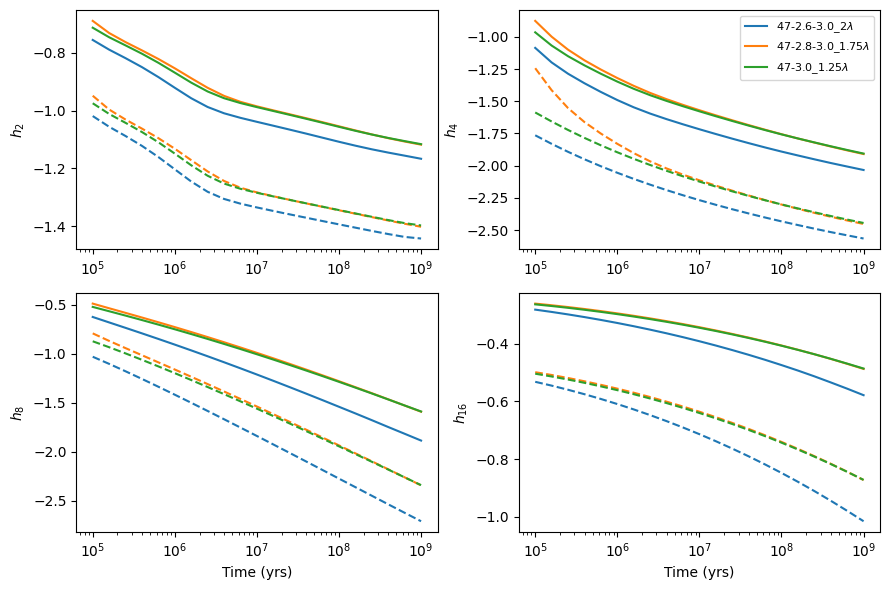

In [6]:
# Plot compressible vs incompressible LNs for n=2-4-8-16

fig, ax = plt.subplots(2,2, figsize=(9,6))
ax = ax.ravel()

lab = [ '47-2.6-3.0_2$\lambda$', '47-2.8-3.0_1.75$\lambda$', '47-3.0_1.25$\lambda$' ]

for i in range(4):
    for j in range(3):
        line, = ax[i].semilogx( t*1000, hLove[j][i,:], label=lab[j] )
        ax[i].semilogx(t*1000, hcLove[j][i,:], color=line.get_color(), linestyle='--')
    ax[i].set_ylabel( '$h_{'+str(ndeg[i])+'}$' )
    #ax[i].set_ylabel( '$h_{'+str(ndeg[i])+'}$', fontname="Arial" )
    if i>1:
        #ax[i].set_xlabel( 'Time (yrs)', fontname="Arial" )
        ax[i].set_xlabel( 'Time (yrs)' )
    #for tick in ax[i].get_xticklabels():
    #    tick.set_fontname("Arial")
    #    tick.set_fontsize(10)
    #for tick in ax[i].get_yticklabels():
    #    tick.set_fontname("Arial")
        
#for i in range(2):
#    ax[i].set_xlabel( 'Time (yrs)' )
#    ax[i].set_ylabel( '$h_{'+str(ndeg[i])+'}$ LLN' )

l=ax[1].legend(fontsize=8)
#plt.setp(l.texts, family='Arial')

plt.tight_layout()

In [7]:
# Compute the deformation profiles for a disc load

t_disc = np.array([1e2, 1e3, 4e3])
n_disc = np.arange(1,51)
dt     = 0.1

hDisc = []
lDisc = []
kDisc = []

hcDisc = []
lcDisc = []
kcDisc = []

hdotDisc = []
ldotDisc = []
kdotDisc = []

hcdotDisc = []
lcdotDisc = []
kcdotDisc = []

for i in range(nmod):
    print( 'Model: ' + models_name[i] )
    # Retrieve the profile
    r   = models_r[i]
    rho = models_rho[i]
    mu  = models_mu[i]
    eta = models_eta[i]
    # Define the rheology
    rheology = models_rheology[i]
    rpar = np.zeros( (len(r),2) )
    # Compute the incompressible LNs
    hh, ll, kk = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n_disc, t_disc, 'loading', 'heaviside', verbose=False )
    hDisc.append( hh )
    lDisc.append( ll )
    kDisc.append( kk )
    hh1, ll1, kk1 = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n_disc, t_disc-dt, 'loading', 'heaviside', verbose=False )
    hh2, ll2, kk2 = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n_disc, t_disc+dt, 'loading', 'heaviside', verbose=False )
    hdotDisc.append( (hh2-hh1)/(2*dt)/1000 )
    ldotDisc.append( (ll2-ll1)/(2*dt)/1000 )
    kdotDisc.append( (kk2-kk1)/(2*dt)/1000 )
    # Compute the compressible LNs
    lam = np.copy(mu)
    hh, ll, kk = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_disc, t_disc, 'loading', 'heaviside', verbose=False )
    hcDisc.append( hh )
    lcDisc.append( ll )
    kcDisc.append( kk )
    hh1, ll1, kk1 = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_disc, t_disc-dt, 'loading', 'heaviside', verbose=False )
    hh2, ll2, kk2 = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_disc, t_disc+dt, 'loading', 'heaviside', verbose=False )
    hcdotDisc.append( (hh2-hh1)/(2*dt)/1000 )
    lcdotDisc.append( (ll2-ll1)/(2*dt)/1000 )
    kcdotDisc.append( (kk2-kk1)/(2*dt)/1000 )




Model: 47-2600-3000_2GRS
Model: 47-2800-3000_1.75GRS
Model: 47-3000_1.25GRS


In [8]:
from scipy.special import eval_legendre

a       = models_r[0][-1]
rho_cap = 1200                          # density of polar cap
h_cap   = 3000                          # thickness of polar cap
alpha   = 1000e3 / 2 / a * 180/np.pi    # angular half-amplitude of polar cap (diameter is 1000km)

dkm   = np.linspace(0,1200,150)
theta = dkm*1000/a * 180/np.pi

sind  = lambda x: np.sin(x * np.pi / 180)
cosd  = lambda x: np.cos(x * np.pi / 180)

sigma = np.zeros( n_disc.shape )

for i in range(len(n_disc)):
    sigma[i] = ( eval_legendre(n_disc[i]-1, cosd(alpha)) - eval_legendre(n_disc[i]+1, cosd(alpha)) ) / 2

u    = [ np.zeros( (len(theta), len(t_disc)) ) ] * nmod
udot = [ np.zeros( (len(theta), len(t_disc)) ) ] * nmod

uc    = [ np.zeros( (len(theta), len(t_disc)) ) ] * nmod
ucdot = [ np.zeros( (len(theta), len(t_disc)) ) ] * nmod


def model_mass(r,rho):
    m =  4/3 * np.pi * r[0]**3 * rho[0]
    m += np.sum( 4/3 * np.pi * (r[1:]**3 - r[:-1]**3) * rho[1:] )
    return m

for i in range(nmod):
    mass = model_mass( models_r[i], models_rho[i] )
    for j in range(len(n_disc)):
        leg = eval_legendre( n_disc[j], cosd(theta) )
        for k in range(len(t_disc)):
            u[i][:,k]    += sigma[j] * hDisc[i][j,k]    / (2*n_disc[j]+1) * leg
            udot[i][:,k] += sigma[j] * hdotDisc[i][j,k] / (2*n_disc[j]+1) * leg
            uc[i][:,k]    += sigma[j] * hcDisc[i][j,k]    / (2*n_disc[j]+1) * leg
            ucdot[i][:,k] += sigma[j] * hcdotDisc[i][j,k] / (2*n_disc[j]+1) * leg

    u[i]    = u[i]    * (4*np.pi*a**3/mass) * rho_cap*h_cap 
    udot[i] = udot[i] * (4*np.pi*a**3/mass) * rho_cap*h_cap 

    uc[i]    = uc[i]    * (4*np.pi*a**3/mass) * rho_cap*h_cap 
    ucdot[i] = ucdot[i] * (4*np.pi*a**3/mass) * rho_cap*h_cap 
    


t=4000.0kyr


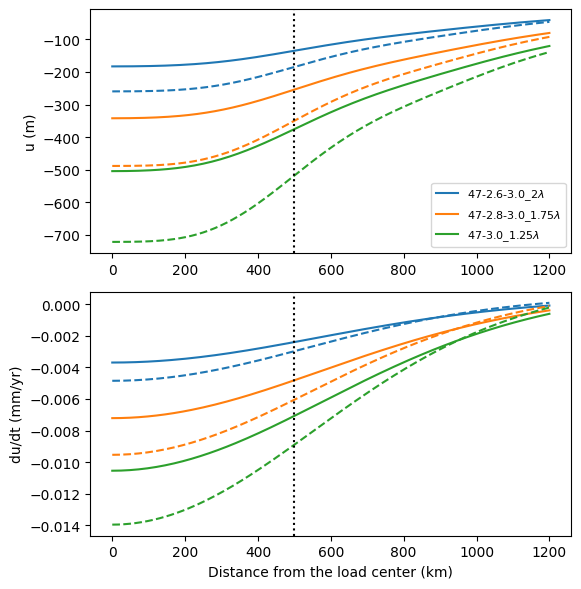

In [9]:

idx_t=2
print( 't='+str(t_disc[idx_t])+'kyr' )

fig, ax = plt.subplots(2,1, figsize=(6,6))

for i in range(3):
    
    #line, = ax[0].plot(theta, u[i][:,idx_t], label=lab[i] )
    #ax[0].plot(theta, uc[i][:,idx_t], color=line.get_color(), linestyle='--' )
    line, = ax[0].plot(dkm, u[i][:,idx_t], label=lab[i] )
    ax[0].plot(dkm, uc[i][:,idx_t], color=line.get_color(), linestyle='--' )    

    #line, = ax[1].plot(theta, udot[i][:,idx_t]*1000 )
    #ax[1].plot(theta, ucdot[i][:,idx_t]*1000, color=line.get_color(), linestyle='--' )
    line, = ax[1].plot(dkm, udot[i][:,idx_t]*1000 )
    ax[1].plot(dkm, ucdot[i][:,idx_t]*1000, color=line.get_color(), linestyle='--' )

ax[0].set_ylabel( 'u (m)' )
ax[1].set_ylabel( 'du/dt (mm/yr)' )
#ax[1].set_xlabel( '$\\theta$ (deg)')
ax[1].set_xlabel( 'Distance from the load center (km)')

ax[0].legend( fontsize=8 )

ax[0].axvline(x=500,color='k',linestyle=':')
ax[1].axvline(x=500,color='k',linestyle=':')

plt.tight_layout()
